In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import random
import os
from src.mypackage.data_preparation import prepare_prophet_data

random.seed(42)
np.random.seed(42)

In [2]:
df = pd.read_csv("../data/raw/PJME_hourly.csv")
train, test = prepare_prophet_data(df)

In [3]:
m = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)
m.add_country_holidays(country_name="US")
m.add_regressor("is_weekend")
m.fit(train)

17:54:21 - cmdstanpy - INFO - Chain [1] start processing
17:57:15 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
# 1年先を予測
future = m.make_future_dataframe(periods=len(test), freq='h')
future["is_weekend"] = future["ds"].dt.weekday >= 5
future.tail()

,ds,is_weekend
145358,2018-08-02 20:00:00,False
145359,2018-08-02 21:00:00,False
145360,2018-08-02 22:00:00,False
145361,2018-08-02 23:00:00,False
145362,2018-08-03 00:00:00,False


In [6]:
forecast = m.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Christmas Day (observed),...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
145358,2018-08-02 20:00:00,31064.392873,36177.469570,48473.607308,27154.753640,34947.049674,0.0,0.0,0.0,0.0,...,593.810952,593.810952,593.810952,5901.096246,5901.096246,5901.096246,0.0,0.0,0.0,41993.449000
145359,2018-08-02 21:00:00,31064.369600,35173.603509,47755.066939,27153.995765,34947.620848,0.0,0.0,0.0,0.0,...,580.057764,580.057764,580.057764,5896.324439,5896.324439,5896.324439,0.0,0.0,0.0,41205.412542
145360,2018-08-02 22:00:00,31064.346326,33105.914580,46163.770347,27153.237890,34948.192021,0.0,0.0,0.0,0.0,...,566.929269,566.929269,566.929269,5891.552776,5891.552776,5891.552776,0.0,0.0,0.0,39578.675101
145361,2018-08-02 23:00:00,31064.323052,30966.248147,43784.826941,27152.480015,34948.763194,0.0,0.0,0.0,0.0,...,554.402924,554.402924,554.402924,5886.781352,5886.781352,5886.781352,0.0,0.0,0.0,37394.591312
145362,2018-08-03 00:00:00,31064.299779,29172.499907,41018.081791,27151.722140,34949.334367,0.0,0.0,0.0,0.0,...,542.428030,542.428030,542.428030,5882.010260,5882.010260,5882.010260,0.0,0.0,0.0,35105.298678


In [8]:
print(train.shape)
print(test.shape)
print(forecast.shape)

(136606, 8)
(8760, 8)
(145363, 73)


In [9]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

mae = mean_absolute_error(test["y"], forecast["yhat"][-len(test):])
rmse = root_mean_squared_error(test["y"], forecast["yhat"][-len(test):])
mape = mean_absolute_percentage_error(test["y"], forecast["yhat"][-len(test):])

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape*100:.2f}%")

MAE: 3230.34, RMSE: 4206.20, MAPE: 10.20%


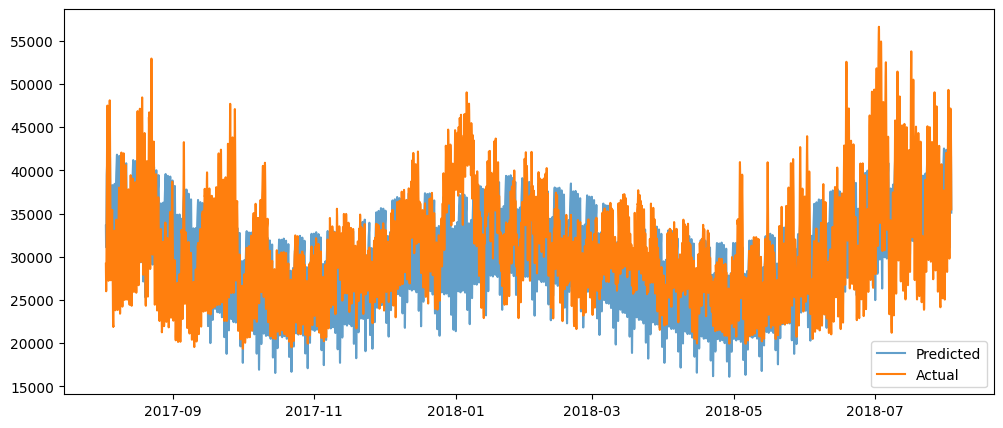

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(test["ds"], forecast["yhat"][-len(test):], label="Predicted", alpha=0.7)
plt.plot(test["ds"], test["y"].values, label="Actual")
plt.legend()
plt.show()

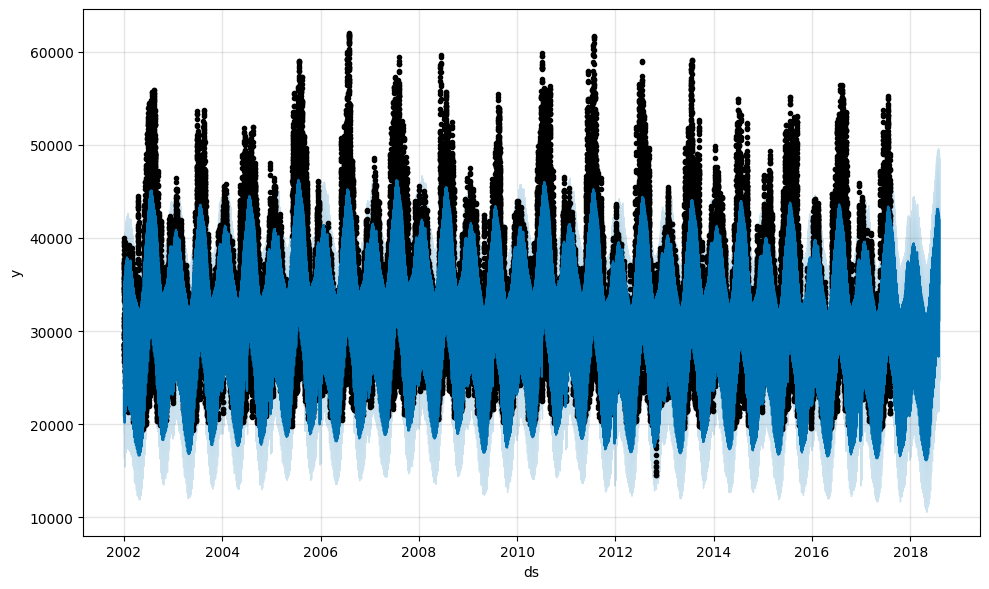

In [10]:
fig1 = m.plot(forecast)

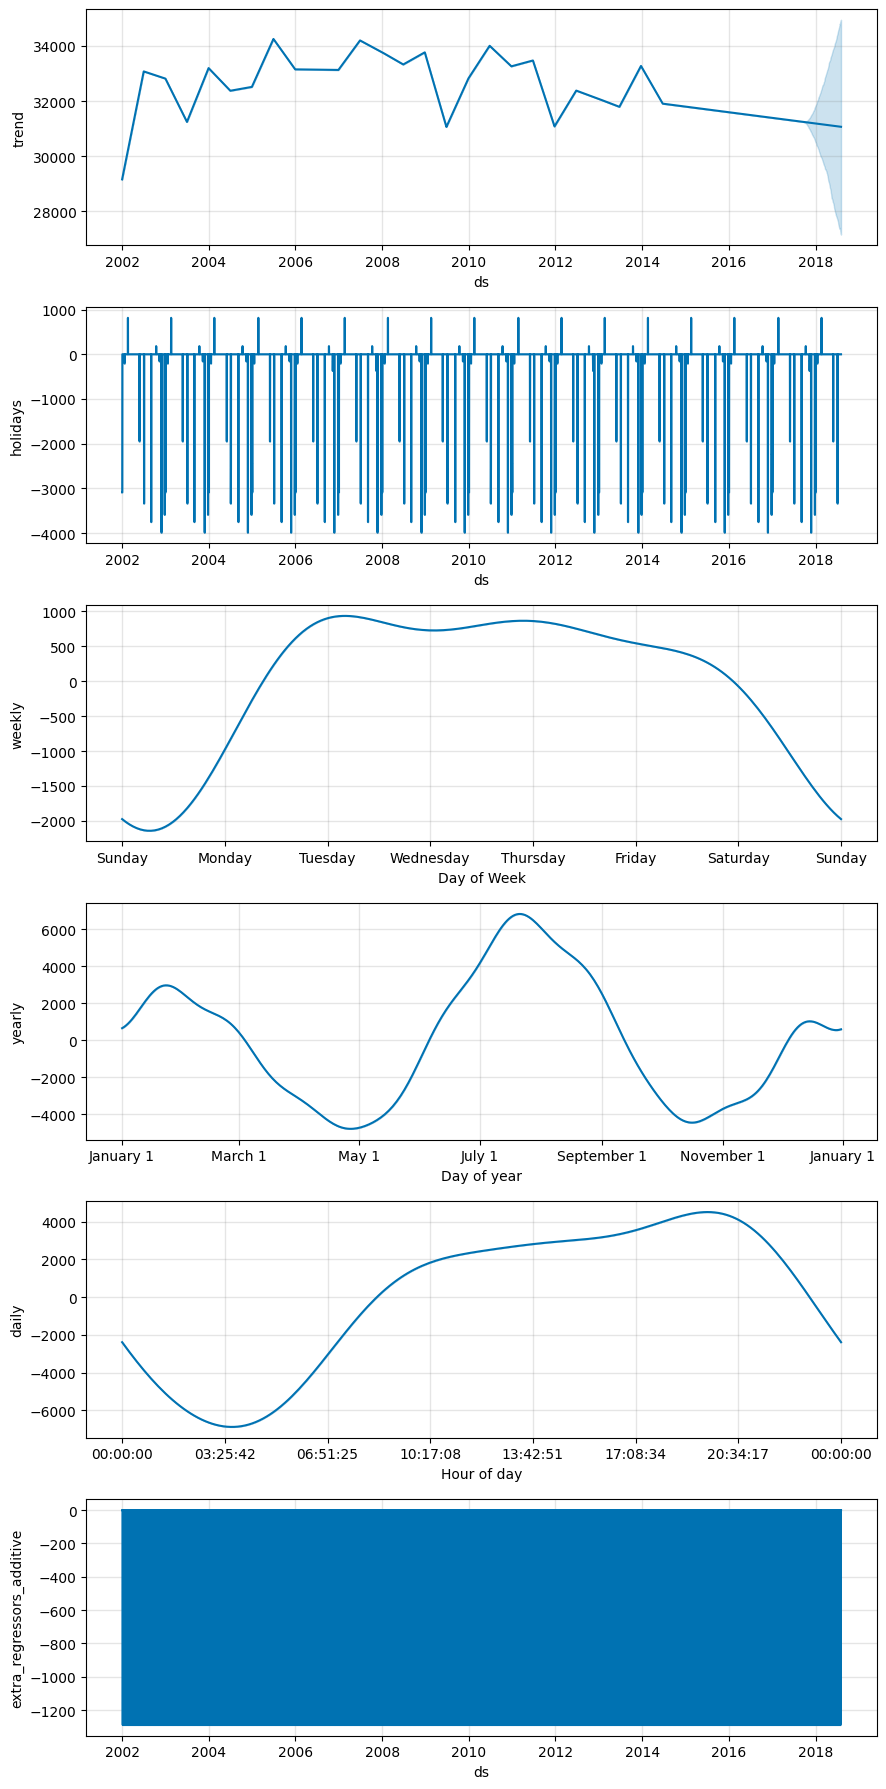

In [11]:
fig2 = m.plot_components(forecast)

In [21]:
def baseline_forecast(train, test, len_pred):
    q, r = divmod(len(test), len_pred)
    df = pd.concat([train, test], axis=0, ignore_index=True)
    if r > 0:
        q += 1
    else:
        r = len_pred
    pred = []
    for t in range(q):
        start = len(train) - len_pred + t * len_pred
        if t == q - 1:
            end = start + r
        else:
            end = start + len_pred
        pred.extend(df["y"][start:end])
    return pred

In [26]:
baseline_forecast_1day = baseline_forecast(train, test, 24)
baseline_forecast_1week = baseline_forecast(train, test, 24*7)
baseline_forecast_1month = baseline_forecast(train, test, 24*30)
baseline_forecast_1year = baseline_forecast(train, test, 24*365)

In [23]:
mae = mean_absolute_error(test["y"], baseline_forecast_1day)
rmse = root_mean_squared_error(test["y"], baseline_forecast_1day)
mape = mean_absolute_percentage_error(test["y"], baseline_forecast_1day)

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape*100:.2f}%")

MAE: 2307.33, RMSE: 3146.25, MAPE: 7.32%


In [24]:
mae = mean_absolute_error(test["y"], baseline_forecast_1week)
rmse = root_mean_squared_error(test["y"], baseline_forecast_1week)
mape = mean_absolute_percentage_error(test["y"], baseline_forecast_1week)

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape*100:.2f}%")

MAE: 3587.61, RMSE: 4855.54, MAPE: 11.24%


In [25]:
mae = mean_absolute_error(test["y"], baseline_forecast_1month)
rmse = root_mean_squared_error(test["y"], baseline_forecast_1month)
mape = mean_absolute_percentage_error(test["y"], baseline_forecast_1month)

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape*100:.2f}%")

MAE: 4836.11, RMSE: 6175.54, MAPE: 15.31%


In [27]:
mae = mean_absolute_error(test["y"], baseline_forecast_1year)
rmse = root_mean_squared_error(test["y"], baseline_forecast_1year)
mape = mean_absolute_percentage_error(test["y"], baseline_forecast_1year)

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape*100:.2f}%")

MAE: 3915.99, RMSE: 5400.78, MAPE: 12.35%
